In [44]:
from utils import functions
from utils import config
from utils import plotting_numeric
from utils import bigquery_functions
from utils.logger_config import setup_logger

%matplotlib inline
import matplotlib.pyplot as plt
import concurrent.futures
import queue
import numpy as np
import pandas as pd
import geopandas as gpd
import os

import seaborn as sns

import contextily as cx
from mpl_toolkits.axes_grid1 import make_axes_locatable

import tempfile
import mercantile
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm

province_index = 0

In [45]:
query_master_data_pilpres_2024 = (
    """
    SELECT * FROM `personal-nurfaldi.datakota.master_data_pilpres_2024_bq`
    """
)

df_master_data_pilpres_2024 = bigquery_functions.query_bq(query_master_data_pilpres_2024)



/Users/nurfaldi/datakota/politico/venv/lib/python3.9/site-packages/google/cloud/bigquery/table.py:1727: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [46]:
df_kelurahan_demographics = pd.read_csv('data_2/demography/all_merged.csv')
df_master_data = pd.merge(
    df_master_data_pilpres_2024,
    df_kelurahan_demographics.add_prefix('demo__'),
    left_on='KODE_KEL_DESA',
    right_on='demo__KODE_KEL_DESA',
    how='left',
    suffixes=('', '_dup')
)

# Drop duplicate columns
col_to_drop = [
    'demo__KODE_KEL_DESA', 
    'demo__KODE_KECAMATAN', 
    'demo__KODE_KAB_KOTA', 
    'demo__KODE_PROVINSI', 
    # 'demo__NAMA_KEL_DESA', 
    # 'demo__NAMA_KECAMATAN', 
    # 'demo__NAMA_KAB_KOTA', 
    # 'demo__NAMA_PROVINSI',
]
df_master_data.drop(columns=col_to_drop, inplace=True)

# Rename columns
col_to_rename = {
    'demo__NAMA_KEL_DESA' : 'NAMA_KEL_DESA', 
    'demo__NAMA_KECAMATAN' : 'NAMA_KECAMATAN', 
    'demo__NAMA_KAB_KOTA' : 'NAMA_KAB_KOTA', 
    'demo__NAMA_PROVINSI' : 'NAMA_PROVINSI'
}
df_master_data.rename(columns=col_to_rename, inplace=True)

# Identify columns that have the '_dup' suffix
columns_to_remove = [col for col in df_master_data.columns if '_dup' in col]
unnamed_columns = df_master_data.columns[df_master_data.columns.str.match(r'^Unnamed:')]

# Remove the identified duplicate columns
df_master_data.drop(columns=columns_to_remove, inplace=True, errors='ignore')
df_master_data.drop(columns=unnamed_columns, inplace=True, errors='ignore')

df_master_data = df_master_data[df_master_data['KODE_PROVINSI'].isin(["74", "31"])]

# lowercase all columns
df_master_data.columns = df_master_data.columns.str.lower()
df_master_data.columns = [functions.sanitize_column_name(col) for col in df_master_data.columns]

# fill missing values
df_master_data.fillna(0, inplace=True)

# Calculate Target
df_master_data['estimasi_suara_tina_nur_alam'] = df_master_data['persen_tina__sultra_kab'] * df_master_data['asumsi_total_suara_dpt']

# for col in ['populasi', 'jumlah_kk', 'kode_desa', 'u0', 'u5', 'cerai_mati']:
#     join_demographic_data[col] = join_demographic_data['total_suara_dpt'] * join_demographic_data[col].fillna(0)


/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_89674/508486762.py:1: DtypeWarning: Columns (2,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_kelurahan_demographics = pd.read_csv('data_2/demography/all_merged.csv')


### Define Columns

In [47]:
columns = df_master_data.columns

base_data_columns = [
    'kode_provinsi',
    'kode_kab_kota',
    'kode_kec',
    'kode_kel_desa',
    'nama_provinsi',
    'nama_kab_kota',
    'nama_kecamatan',
    'nama_kel_desa',
    'paslon01',
    'paslon02',
    'paslon03',
    'total_suara_sah',
    'suara_tidak_sah',
    'asumsi_total_suara_dpt'
]

sultra_columns = ["persen_nasdem__sultra_kab", "undecided__sultra_kab", "tina_vs_others__sultra_kab"]
other_metrics = ['paslon01','paslon02','paslon03','total_suara_sah', 'suara_tidak_sah']

demo_columns = [col for col in columns if col.startswith('demo__')]
drop_cols = [
    'demo__kode',
    'demo__luas_ha',
    'demo__luas_sqkm',
    'demo__populasi',
    'demo__jumlah_kk',
    'demo__kode_desa'
]

# delete drop cols from demo cols
demo_columns = [col for col in demo_columns if col not in drop_cols]

In [48]:
# # Check autocorrelation on demo__ columns
# columns = df_master_data.columns
# demo_columns = [col for col in columns if col.startswith('demo__')]
# sultra_columns = ["persen_nasdem__sultra_kab", "persen_tina__sultra_kab", "undecided__sultra_kab", "tina_vs_others__sultra_kab"]
# other_metrics = ['paslon01','paslon02','paslon03']
# drop_cols = ["demo__luas"]

# corr_columns = demo_columns + sultra_columns + other_metrics
# autocorr = df_master_data[corr_columns][df_master_data['kode_provinsi'].isin(["74"])].corr()
# autocorr = (autocorr * 100).round(0)

# # # Print autocorrelation matrix
# # print("Autocorrelation Matrix:")
# # print(autocorr)

# # Visualize autocorrelation matrix (optional)
# plt.figure(figsize=(50, 50))
# sns.heatmap(autocorr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
# plt.title('Autocorrelation Matrix')
# plt.show()


# DKI

In [49]:
df_dki = df_master_data[df_master_data['kode_provinsi'].isin(["31"])].copy()
dependent_variable = 'paslon01'

In [50]:
df_dki_corr = df_dki[[dependent_variable] + demo_columns].corr().iloc[0, 1:]

df_dki['demo_conversion_factor'] = 0

weight_columns = []
for feature in demo_columns:
    correlation_value = df_dki_corr[feature]
    # Skip the feature if the correlation is NaN
    if pd.isna(correlation_value):
        continue

    weight_feature_name = feature + '_weight'
    df_dki[weight_feature_name] = df_dki[feature] / df_dki['demo__populasi']

    df_dki['demo__populasi'] = df_dki['demo__populasi'].fillna(1)  # Handle NaN in denominator, assuming fill with 1 is appropriate
    # Safe divide with numpy
    df_dki[weight_feature_name] = np.divide(df_dki[feature], df_dki['demo__populasi'], out=np.zeros_like(df_dki[feature]), where=(df_dki['demo__populasi'] != 0))

    weight_columns.append(weight_feature_name)

    correlation_value = df_dki_corr[feature]
    df_dki['demo_conversion_factor'] += correlation_value * df_dki[weight_feature_name].fillna(0)
    
df_dki['demo_conversion_factor_normalized'] = df_dki['demo_conversion_factor']/max(df_dki['demo_conversion_factor'])


/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_89674/3292325877.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_dki[weight_feature_name] = df_dki[feature] / df_dki['demo__populasi']
/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_89674/3292325877.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_dki[weight_feature_name] = df_dki[feature] / df_dki['demo__populasi']
/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_89674/3292325877.py:13: PerformanceWarning: DataFrame is highly fragmen

In [51]:
df_dki.columns.to_list()

['kode_provinsi',
 'kode_kab_kota',
 'kode_kec',
 'kode_kel_desa',
 'paslon01',
 'paslon02',
 'paslon03',
 'total_suara_sah',
 'suara_tidak_sah',
 'asumsi_total_suara_dpt',
 'persen_nasdem__sultra_kab',
 'persen_tina__sultra_kab',
 'undecided__sultra_kab',
 'tina_vs_others__sultra_kab',
 'aniessandi_pilgub__dki',
 'total_suara_sah_pilgub__dki',
 'nama_kel_desa',
 'nama_kecamatan',
 'nama_kab_kota',
 'nama_provinsi',
 'demo__kode',
 'demo__luas_ha',
 'demo__luas_sqkm',
 'demo__populasi',
 'demo__jumlah_kk',
 'demo__kode_desa',
 'demo__u0',
 'demo__u5',
 'demo__u10',
 'demo__u15',
 'demo__u20',
 'demo__u25',
 'demo__u30',
 'demo__u35',
 'demo__u40',
 'demo__u45',
 'demo__u50',
 'demo__u55',
 'demo__u60',
 'demo__u65',
 'demo__u70',
 'demo__u75',
 'demo__usia_balita',
 'demo__usia_sekolah',
 'demo__usia_produktif',
 'demo__usia_lansia',
 'demo__tidak_belum_sekolah',
 'demo__belum_tamat_sd_sederajat',
 'demo__tamat_sd_sederajat',
 'demo__smp_sederajat',
 'demo__sma_sederajat',
 'demo__dipl

/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_89674/2247193313.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_dki['demo_conversion_factor_winsorized'] = winsorize(df_dki['demo_conversion_factor'], limits=limits)
/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_89674/2247193313.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_dki[['demo_conversion_factor_winsorized_normalized']] = scaler.fit_transform(df_dki['demo_conversion_factor_winsorized'].values.reshape(-1, 1))
/var/folders/2_/ldxvm2xd3

array([[<Axes: title={'center': 'aniessandi_pilgub__dki_normalized'}>]],
      dtype=object)

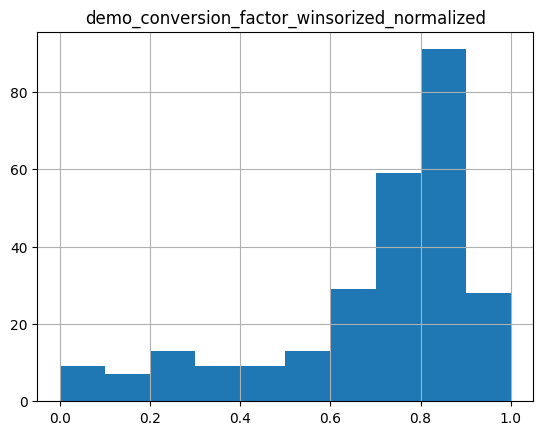

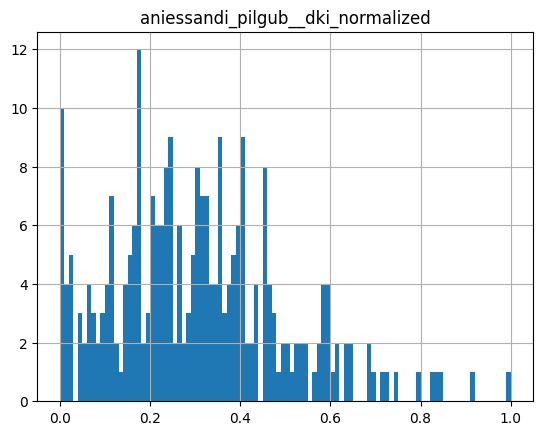

In [52]:
# Normalization by standard scaler
from sklearn.preprocessing import MinMaxScaler
from scipy.stats.mstats import winsorize

# Define the limits for windsorizing (e.g., limit 5% from each end)
limits = [0.02, 0.00]  # Adjust these values as needed

# Apply windsorization
df_dki['demo_conversion_factor_winsorized'] = winsorize(df_dki['demo_conversion_factor'], limits=limits)

# Optionally, normalize the windsorized column
scaler = MinMaxScaler()
df_dki[['demo_conversion_factor_winsorized_normalized']] = scaler.fit_transform(df_dki['demo_conversion_factor_winsorized'].values.reshape(-1, 1))
df_dki[['aniessandi_pilgub__dki_normalized']] = scaler.fit_transform(df_dki[['aniessandi_pilgub__dki']].values.reshape(-1, 1))
# df_dki[['tina_vs_others__sultra_kab_normalized']] = scaler.fit_transform(df_dki[['tina_vs_others__sultra_kab']].values.reshape(-1, 1))

# Plot the histograms
df_dki[['demo_conversion_factor_winsorized_normalized']].hist(bins=10)
df_dki[['aniessandi_pilgub__dki_normalized']].hist(bins=100)
# df_dki[['tina_vs_others__sultra_kab_normalized']].hist(bins=100)


### Calculation

In [53]:
# Define constants
effort_value = 0.5
effort_weight = 0.4
# strength_tina_vs_others = 0.1
strength_pilgub = 0.2
demographic_suitability = 0.4
multiplier = 1.3

# Calculate final conversion rate
df_dki[['final_conversion_rate']] =(df_dki[['demo_conversion_factor_winsorized_normalized']] * demographic_suitability) 
+ (df_dki[['aniessandi_pilgub__dki_normalized']] * strength_pilgub)
# + (df_dki[['tina_vs_others__sultra_kab_normalized']] * strength_tina_vs_others)

df_dki[['final_conversion_rate']] = effort_value * (effort_weight + df_dki[['final_conversion_rate']]) * multiplier
# df_dki[['final_conversion_rate']].hist(bins=100)
# df_dki[['final_conversion_rate']].mean()

# Calculate resource allocation factor based on conversion rate
# Calculate percentiles
percentile_25 = df_dki['final_conversion_rate'].quantile(0.25)
percentile_75 = df_dki['final_conversion_rate'].quantile(0.75)

# Define the function to apply the conditions
def apply_conditions(x):
    if x < percentile_25:
        return 0.7
    elif x > percentile_75:
        return 1.3
    else:
        return 1

# Apply the function to the 'effort_adjusted_conversion_rate' column
df_dki['resource_factor'] = df_dki['final_conversion_rate'].apply(apply_conditions)

# Calculate columns
df_dki['converted_votes_if_all_approached'] = df_dki['final_conversion_rate'] * df_dki['asumsi_total_suara_dpt']

# Calculate weighted sumproduct of R and S
overtarget_factor = (df_dki['converted_votes_if_all_approached'] * df_dki['resource_factor']).sum() / df_dki['asumsi_total_suara_dpt'].sum()
print(overtarget_factor)



0.4663093136252044


/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_89674/1946090653.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_dki[['final_conversion_rate']] =(df_dki[['demo_conversion_factor_winsorized_normalized']] * demographic_suitability)
/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_89674/1946090653.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_dki['resource_factor'] = df_dki['final_conversion_rate'].apply(apply_conditions)
/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_89674/1946090

<Axes: >

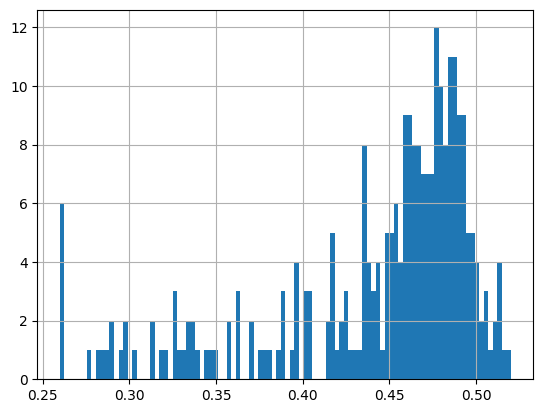

In [54]:
df_dki['final_conversion_rate'].hist(bins=100)

In [55]:
# Constants
DPT_per_households = 1.42
# households_per_volunteer_per_day = 3
valid_votes_per_DPT = 0.57
volunteer_target_households = 100

# months_to_end_of_door_to_door = 5
# working_days_per_month = 20

target_suara_35 = 0.35
target_suara_51 = 0.51

# Example DataFrame (replace this with your actual data)
# df_dki = pd.DataFrame({
#     'converted_votes_if_all_approached': [100, 200, 300],
#     'resource_factor': [1, 0.9, 1.1],
#     'final_conversion_rate': [0.1, 0.2, 0.15]
# })

# Function to calculate metrics for a given target_suara
def calculate_metrics(df, target_suara, suffix):
    df[f'target_voters_{suffix}'] = (target_suara * df['converted_votes_if_all_approached'] * df['resource_factor']) / overtarget_factor
    df[f'no_of_people_reached_{suffix}'] = df[f'target_voters_{suffix}'] / df['final_conversion_rate']
    df[f'house_visit_target_{suffix}'] = df[f'no_of_people_reached_{suffix}'] / DPT_per_households
    # df[f'door_to_door_per_day_target_{suffix}'] = df[f'house_visit_target_{suffix}'] / (working_days_per_month * months_to_end_of_door_to_door)
    # df[f'volunteer_needs_{suffix}'] = df[f'door_to_door_per_day_target_{suffix}'] / households_per_volunteer_per_day
    df[f'volunteer_needs_{suffix}'] = df[f'house_visit_target_{suffix}'] / volunteer_target_households

# Calculate metrics for both targets
calculate_metrics(df_dki, target_suara_35, '35')
calculate_metrics(df_dki, target_suara_51, '51')

# Define the columns for export and plot
metrics_data_columns_35 = [
    'resource_factor', 
    'final_conversion_rate', 
    'target_voters_35', 
    'no_of_people_reached_35', 
    'house_visit_target_35', 
    # 'door_to_door_per_day_target_35', 
    'volunteer_needs_35'
]

metrics_data_columns_51 = [
    'resource_factor', 
    'final_conversion_rate', 
    'target_voters_51', 
    'no_of_people_reached_51', 
    'house_visit_target_51', 
    # 'door_to_door_per_day_target_51', 
    'volunteer_needs_51'
]

# Assuming base_data_columns is defined
# base_data_columns = ['column1', 'column2', 'column3']  # Replace with actual column names

df_dki_export = df_dki[base_data_columns + metrics_data_columns_35 + metrics_data_columns_51]
df_dki_plot = df_dki[base_data_columns + metrics_data_columns_35 + metrics_data_columns_51]


/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_89674/209768696.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'target_voters_{suffix}'] = (target_suara * df['converted_votes_if_all_approached'] * df['resource_factor']) / overtarget_factor
/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_89674/209768696.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'no_of_people_reached_{suffix}'] = df[f'target_voters_{suffix}'] / df['final_conversion_rate']
/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp

In [56]:
df_dki_plot.rename(columns={
    'total_suara_sah' : 'Total Suara Sah Pilpres',
    'asumsi_total_suara_dpt': 'Total Suara DPT',
    'target_voters_35': 'Target Suara 35%',
    'no_of_people_reached_35': 'Target Orang yang Ditemui 35%',
    'house_visit_target_35': 'Target Visit Rumah 35%',
    # 'door_to_door_per_day_target_35': 'Target D2D Perhari 35%',
    'volunteer_needs_35': 'Kebutuhan Relawan 35%',
    'target_voters_51': 'Target Suara 51%',
    'no_of_people_reached_51': 'Target Orang yang Ditemui 51%',
    'house_visit_target_51': 'Target Visit Rumah 51%',
    # 'door_to_door_per_day_target_51': 'Target D2D Perhari 51%',
    'volunteer_needs_51': 'Kebutuhan Relawan 51%'
}, inplace=True)

plot_list = [
    'Total Suara DPT', 
    'Target Suara 35%', 
    'Target Orang yang Ditemui 35%',
    'Target Visit Rumah 35%', 
    # 'Target D2D Perhari 35%', 
    'Kebutuhan Relawan 35%',
    'Target Suara 51%', 
    'Target Orang yang Ditemui 51%', 
    'Target Visit Rumah 51%',
    # 'Target D2D Perhari 51%', 
    'Kebutuhan Relawan 51%'

]

kel_list = list(df_dki_plot.nama_kel_desa.unique())
kec_list = list(df_dki_plot.nama_kecamatan.unique())
kab_list = list(df_dki_plot.nama_kab_kota.unique())

df_dki_plot.info()

<class 'pandas.core.frame.DataFrame'>
Index: 267 entries, 0 to 266
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   kode_provinsi                  267 non-null    object 
 1   kode_kab_kota                  267 non-null    object 
 2   kode_kec                       267 non-null    object 
 3   kode_kel_desa                  267 non-null    object 
 4   nama_provinsi                  267 non-null    object 
 5   nama_kab_kota                  267 non-null    object 
 6   nama_kecamatan                 267 non-null    object 
 7   nama_kel_desa                  267 non-null    object 
 8   paslon01                       267 non-null    Int64  
 9   paslon02                       267 non-null    Int64  
 10  paslon03                       267 non-null    Int64  
 11  Total Suara Sah Pilpres        267 non-null    Int64  
 12  suara_tidak_sah                267 non-null    Int64  


/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_89674/2542597885.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dki_plot.rename(columns={


In [57]:
df_dki_plot[df_dki_plot.nama_kab_kota != 0]

,kode_provinsi,kode_kab_kota,kode_kec,kode_kel_desa,nama_provinsi,nama_kab_kota,nama_kecamatan,nama_kel_desa,paslon01,paslon02,...,Target Suara 35%,Target Orang yang Ditemui 35%,Target Visit Rumah 35%,Kebutuhan Relawan 35%,resource_factor,final_conversion_rate,Target Suara 51%,Target Orang yang Ditemui 51%,Target Visit Rumah 51%,Kebutuhan Relawan 51%
0,31,31.01,31.01.01,31.01.01.1002,DKI Jakarta,Administrasi Kepulauan Seribu,Kepulauan Seribu Utara,Pulau Kelapa,1894,2750,...,3083.780728,7075.668239,4982.864957,49.82865,1.0,0.435829,4493.509061,10310.259434,7260.74608,72.607461
1,31,31.01,31.01.01,31.01.01.1001,DKI Jakarta,Administrasi Kepulauan Seribu,Kepulauan Seribu Utara,Pulau Panggang,1410,1942,...,2355.635322,5229.254336,3682.573476,36.825735,1.0,0.450473,3432.497184,7619.770603,5366.035636,53.660356
2,31,31.01,31.01.01,31.01.01.1003,DKI Jakarta,Administrasi Kepulauan Seribu,Kepulauan Seribu Utara,Pulau Harapan,658,827,...,645.472527,1549.411472,1091.134839,10.911348,0.7,0.416592,940.545683,2257.713859,1589.939337,15.899393
3,31,31.01,31.01.02,31.01.02.1001,DKI Jakarta,Administrasi Kepulauan Seribu,Kepulauan Seribu Selatan,Pulau Untung Jawa,783,610,...,906.043799,2010.039201,1415.520564,14.155206,1.0,0.450759,1320.23525,2928.914264,2062.615679,20.626157
4,31,31.01,31.01.02,31.01.02.1003,DKI Jakarta,Administrasi Kepulauan Seribu,Kepulauan Seribu Selatan,Pulau Pari,771,1246,...,824.023442,2074.2884,1460.766479,14.607665,0.7,0.397256,1200.719873,3022.534526,2128.545441,21.285454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,31,31.75,31.75.10,31.75.10.1006,DKI Jakarta,Kota Administrasi Jakarta Timur,Cipayung,Bambu Apus,2270,2803,...,3570.96434,7565.042981,5327.495057,53.274951,1.0,0.472035,5203.405181,11023.348344,7762.921369,77.629214
263,31,31.75,31.75.10,31.75.10.1007,DKI Jakarta,Kota Administrasi Jakarta Timur,Cipayung,Lubang Buaya,14386,13582,...,26286.482743,53976.382767,38011.53716,380.115372,1.3,0.487000,38303.160569,78651.300603,55388.239861,553.882399
264,31,31.75,31.75.10,31.75.10.1002,DKI Jakarta,Kota Administrasi Jakarta Timur,Cipayung,Cilangkap,4678,4924,...,6630.225057,14556.646847,10251.159752,102.511598,1.0,0.455477,9661.185083,21211.113977,14937.404209,149.374042
265,31,31.75,31.75.10,31.75.10.1004,DKI Jakarta,Kota Administrasi Jakarta Timur,Cipayung,Munjul,4162,4574,...,6314.45919,13321.200796,9381.127321,93.811273,1.0,0.474016,9201.069105,19410.892589,13669.642668,136.696427


In [58]:
# numeric_cols = df_sultra_plot.select_dtypes(include=['number']).columns.tolist()
# non_numeric_cols = df_sultra_plot.select_dtypes(exclude=['number']).columns.tolist()
# ratio_cols = ['resource_factor', 'final_conversion_rate']

# agg_dict = {col: 'sum' for col in numeric_cols}
# agg_dict.update({col: 'mean' for col in ratio_cols})
# agg_dict.update({col: any_value for col in non_numeric_cols})

# agg_dict

In [59]:
df_dki_plot.info()

<class 'pandas.core.frame.DataFrame'>
Index: 267 entries, 0 to 266
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   kode_provinsi                  267 non-null    object 
 1   kode_kab_kota                  267 non-null    object 
 2   kode_kec                       267 non-null    object 
 3   kode_kel_desa                  267 non-null    object 
 4   nama_provinsi                  267 non-null    object 
 5   nama_kab_kota                  267 non-null    object 
 6   nama_kecamatan                 267 non-null    object 
 7   nama_kel_desa                  267 non-null    object 
 8   paslon01                       267 non-null    Int64  
 9   paslon02                       267 non-null    Int64  
 10  paslon03                       267 non-null    Int64  
 11  Total Suara Sah Pilpres        267 non-null    Int64  
 12  suara_tidak_sah                267 non-null    Int64  


In [60]:
# Stopper TODO make 3 level GeoJSON
# Read the GeoJSON file
dki_kel_geojson = 'DKI.geojson'
geojson_col_list = [
    "KODE_KEL_DESA",  
    "KODE_KEC",  
    "KODE_KAB_KOTA",  
    "KODE_PROVINSI",  
    "NAMA_KEL_DESA",  
    "NAMA_KECAMATAN",  
    "NAMA_KAB_KOTA",  
    "NAMA_PROVINSI",  
    'geometry'
]

# Columns to keep after dissolve
kec_col_list = [
    "KODE_KEC",  
    "KODE_KAB_KOTA",  
    "KODE_PROVINSI",  
    "NAMA_KECAMATAN",  
    "NAMA_KAB_KOTA",  
    "NAMA_PROVINSI",  
    'geometry'
]
kab_col_list = [
    "KODE_KAB_KOTA",  
    "KODE_PROVINSI",  
    "NAMA_KAB_KOTA",  
    "NAMA_PROVINSI",  
    'geometry'
]

# Load GeoDataFrame
gdf_dki_kel = gpd.read_file(dki_kel_geojson)
gdf_dki_kel = gdf_dki_kel[geojson_col_list]

# Dissolve
gdf_dki_kec = gdf_dki_kel.dissolve(by='KODE_KEC', as_index=False)
gdf_dki_kab = gdf_dki_kel.dissolve(by='KODE_KAB_KOTA', as_index=False)

# Select relevant columns
gdf_dki_kec = gdf_dki_kec[kec_col_list]
gdf_dki_kab = gdf_dki_kab[kab_col_list]

In [61]:
import pandas as pd
import geopandas as gpd

def any_value(series):
    return series.iloc[0]

def make_unique(column_name, existing_names):
    """Helper function to make column names unique."""
    counter = 1
    new_name = column_name
    while new_name in existing_names:
        new_name = f"{column_name}_{counter}"
        counter += 1
    return new_name

def join_geojson_dki(df_kel_source):
    gdf_kel = gdf_dki_kel
    gdf_kec = gdf_dki_kec
    gdf_kab = gdf_dki_kab

    df_kel = df_kel_source.copy()

    # Ensure unique column names
    new_columns = []
    existing_names = set()
    for col in df_kel.columns:
        unique_col = make_unique(col, existing_names)
        new_columns.append(unique_col)
        existing_names.add(unique_col)
    df_kel.columns = new_columns

    # Select numeric and non-numeric columns
    numeric_cols = df_kel.select_dtypes(include=['number']).columns.tolist()
    non_numeric_cols = df_kel.select_dtypes(exclude=['number']).columns.tolist()
    ratio_cols = ['resource_factor', 'final_conversion_rate']

    # Remove grouping columns from non-numeric columns
    non_numeric_cols = [col for col in non_numeric_cols if col not in ['kode_kec', 'kode_kab_kota']]

    # Create aggregation dictionary
    agg_dict = {col: 'sum' for col in numeric_cols}
    agg_dict.update({col: 'mean' for col in ratio_cols})
    agg_dict.update({col: any_value for col in non_numeric_cols})

    print("Aggregation Dictionary: ", agg_dict)

    # Group by and aggregate
    df_kec = df_kel.groupby(by='kode_kec').agg(agg_dict).reset_index()
    df_kab_kota = df_kel.groupby(by='kode_kab_kota').agg(agg_dict).reset_index()

    for col in [col for col in numeric_cols if col not in ratio_cols]:
        df_kel[col] = df_kel[col].apply(round).astype(int)
        df_kec[col] = df_kec[col].astype(int)
        df_kab_kota[col] = df_kab_kota[col].astype(int)
        
    # Merge GeoDataFrames with aggregated data
    gdf_merge_kel = pd.merge(gdf_kel, df_kel, left_on='KODE_KEL_DESA', right_on='kode_kel_desa', how='left')
    gdf_merge_kec = pd.merge(gdf_kec, df_kec, left_on='KODE_KEC', right_on='kode_kec', how='left')
    gdf_merge_kab_kota = pd.merge(gdf_kab, df_kab_kota, left_on='KODE_KAB_KOTA', right_on='kode_kab_kota', how='left')
    
    return gdf_merge_kel, gdf_merge_kec, gdf_merge_kab_kota

# Example usage with df_dki_export DataFrame
gdf_merge_kel_dki, gdf_merge_kec_dki, gdf_merge_kab_kota_dki = join_geojson_dki(df_dki_plot)
gdf_merge_kab_kota_dki.info()

Aggregation Dictionary:  {'paslon01': 'sum', 'paslon02': 'sum', 'paslon03': 'sum', 'Total Suara Sah Pilpres': 'sum', 'suara_tidak_sah': 'sum', 'Total Suara DPT': 'sum', 'resource_factor': 'mean', 'final_conversion_rate': 'mean', 'Target Suara 35%': 'sum', 'Target Orang yang Ditemui 35%': 'sum', 'Target Visit Rumah 35%': 'sum', 'Kebutuhan Relawan 35%': 'sum', 'resource_factor_1': 'sum', 'final_conversion_rate_1': 'sum', 'Target Suara 51%': 'sum', 'Target Orang yang Ditemui 51%': 'sum', 'Target Visit Rumah 51%': 'sum', 'Kebutuhan Relawan 51%': 'sum', 'kode_provinsi': <function any_value at 0x30a770310>, 'kode_kel_desa': <function any_value at 0x30a770310>, 'nama_provinsi': <function any_value at 0x30a770310>, 'nama_kab_kota': <function any_value at 0x30a770310>, 'nama_kecamatan': <function any_value at 0x30a770310>, 'nama_kel_desa': <function any_value at 0x30a770310>}
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 30 columns):
 #   Column

In [62]:
kel_cols = ['KODE_KEL_DESA', 'KODE_KEC', 'KODE_KAB_KOTA', 'KODE_PROVINSI', 'NAMA_KEL_DESA', 'NAMA_KECAMATAN', 'NAMA_KAB_KOTA', 'NAMA_PROVINSI']
kec_cols = ['KODE_KEC', 'KODE_KAB_KOTA', 'KODE_PROVINSI', 'NAMA_KECAMATAN', 'NAMA_KAB_KOTA', 'NAMA_PROVINSI']
kab_cols = ['KODE_KAB_KOTA', 'KODE_PROVINSI', 'NAMA_KAB_KOTA', 'NAMA_PROVINSI']

cols_to_export = [
    # 'KODE_KEC', 
    # 'KODE_KAB_KOTA', 
    # 'KODE_PROVINSI', 
    # 'NAMA_KECAMATAN',
    # 'NAMA_KAB_KOTA', 
    # 'NAMA_PROVINSI', 
    # 'LUAS_HA', 
    # 'LUAS_SQKM',
    # 'KODE',
    # 'geometry', 
    # 'kode_kec', 
    # 'paslon01', 
    # 'paslon02', 
    # 'paslon03',
    'Total Suara Sah Pilpres',
    # 'suara_tidak_sah', 
    'Total Suara DPT',
    'resource_factor', 
    'final_conversion_rate', 
    'Target Suara 35%',
    'Target Orang yang Ditemui 35%', 
    'Target Visit Rumah 35%',
    'Kebutuhan Relawan 35%', 
    # 'resource_factor_1', 
    # 'final_conversion_rate_1',
    'Target Suara 51%', 
    'Target Orang yang Ditemui 51%',
    'Target Visit Rumah 51%', 
    'Kebutuhan Relawan 51%', 
    # 'kode_provinsi',
    # 'kode_kel_desa', 
    # 'nama_provinsi', 
    # 'nama_kab_kota', 
    # 'nama_kecamatan',
    # 'nama_kel_desa'
]
df_export_kel_dki_to_gsheet = gdf_merge_kel_dki[kel_cols + cols_to_export].copy()
df_export_kec_dki_to_gsheet = gdf_merge_kec_dki[kec_cols + cols_to_export].copy()
df_export_kab_dki_kota_to_gsheet = gdf_merge_kab_kota_dki[kab_cols + cols_to_export].copy()

df_export_kel_dki_to_gsheet = df_export_kel_dki_to_gsheet.sort_values(by=['KODE_KAB_KOTA', 'KODE_KEC', 'KODE_KEL_DESA'])
df_export_kec_dki_to_gsheet = df_export_kec_dki_to_gsheet.sort_values(by=['KODE_KAB_KOTA', 'KODE_KEC'])
df_export_kab_dki_kota_to_gsheet = df_export_kab_dki_kota_to_gsheet.sort_values(by=['KODE_KAB_KOTA'])


In [63]:
import os
import gspread
from gspread_dataframe import set_with_dataframe
import pandas as pd
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# Get the path to the credentials file from the environment variable
credentials_path = os.getenv('GOOGLE_APPLICATION_CREDENTIALS_PATH')

# Authenticate and open the Google Sheet
gc = gspread.service_account(filename=credentials_path)

# Open the Google Sheet by URL
spreadsheet_url = 'https://docs.google.com/spreadsheets/d/1w0CeipL5m_XyrT7sLxZEAFCfM4dIKvwBAE5kj0PhMis/edit#gid=0'
spreadsheet = gc.open_by_url(spreadsheet_url)

# Select the worksheet by name
worksheet_kel = spreadsheet.worksheet('dki_kelurahan')
worksheet_kec = spreadsheet.worksheet('dki_kecamatan')
worksheet_kab_kota = spreadsheet.worksheet('dki_kab_kota')

# Clear the worksheet (optional)
worksheet_kel.clear()
worksheet_kec.clear()
worksheet_kab_kota.clear()

# Export the DataFrame to Google Sheets
set_with_dataframe(worksheet_kel, df_export_kel_dki_to_gsheet)
set_with_dataframe(worksheet_kec, df_export_kec_dki_to_gsheet)
set_with_dataframe(worksheet_kab_kota, df_export_kab_dki_kota_to_gsheet)

print("DataFrame exported successfully to Google Sheets.")


DataFrame exported successfully to Google Sheets.


In [64]:
stopper

NameError: name 'stopper' is not defined

In [ ]:
base_dir = 'plot_results/RTV_weighted/DKI'
os.makedirs(base_dir, exist_ok=True)

In [ ]:
# Function to download tiles for a given data extent and zoom level
def cache_tiles(data, zoom):
    bounds = data.total_bounds  # Get the bounding box of the data
    # Get the tile bounds at the given zoom level
    tiles = list(mercantile.tiles(bounds[0], bounds[1], bounds[2], bounds[3], zoom))
    
    # Create a temporary directory to store tiles
    with tempfile.TemporaryDirectory() as tmpdirname:
        def download_tile(tile):
            temp_file = os.path.join(tmpdirname, f'{tile.z}_{tile.x}_{tile.y}.tif')
            cx.bounds2raster(*mercantile.xy_bounds(tile), temp_file, source=cx.providers.CartoDB.PositronNoLabels)
            # return f'Tile {tile} cached.'

        with ThreadPoolExecutor(max_workers=100) as executor:
            futures = [executor.submit(download_tile, tile) for tile in tiles]
            for future in tqdm(as_completed(futures), total=len(futures), desc='Caching tiles'):
                result = future.result()
                # print(result)

def get_zoom_level(gdf):
    bounds = gdf.total_bounds  # [minx, miny, maxx, maxy]
    lon_diff = bounds[2] - bounds[0]
    lat_diff = bounds[3] - bounds[1]

    # Calculate zoom level using a logarithmic scale
    lon_zoom = np.log2(360 / lon_diff)
    lat_zoom = np.log2(180 / lat_diff)
    
    # Use the smaller zoom level to fit the entire bounding box
    zoom_level = min(lon_zoom, lat_zoom)
    
    # Ensure the zoom level is within a standard range (0-18)
    zoom_level = max(0, min(18, zoom_level))
    
    # Return the rounded integer zoom level
    return int(round(zoom_level))

zoom = get_zoom_level(gdf_merge_kab_kota_dki)
print(zoom)

0


In [ ]:
def map_numeric_kabupaten(data, col):

    # zoom_level = get_zoom_level(data)

    fig, ax = plt.subplots(figsize=(10, 15))
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", size="3%", pad=0.1)

    data.plot(ax=ax,
        column=col,
        edgecolor='k',
        cmap='Reds',
        linewidth=0.5,
        legend=True,  
        alpha=0.7,
        cax=cax,
        categorical=False,
        legend_kwds={"orientation": "horizontal"},
        missing_kwds={
            "color": "black",
            "edgecolor": "red",
            "label": "Missing values",
        }
    )

    cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels, crs=data.crs, zoom=12)
    ax.set_axis_off()

    title_font = {'fontsize': 20, 'fontweight': 'bold', 'fontname': 'Helvetica'}
    ax.set_title(f"Peta {col} DI DKI Jakarta".upper(), pad=2, loc='left', fontsize=title_font['fontsize'], fontdict=title_font)

    for idx, row in data.iterrows():
        centroid = row.geometry.centroid
        label = f"{row['NAMA_KAB_KOTA']}\n{row[col]:,.0f}"
        ax.text(
            centroid.x, centroid.y, str(label),
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=8,
            color='black',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0.5)
        )
        # Adding the label for Kepulauan Seribu

    kep_seribu_label = f"Administrasi Kepulauan Seribu: {kep_seribu_val}\nPeta tersedia di level kabupaten_kota"
    ax.text(
        0.5, 0.96, kep_seribu_label,
        horizontalalignment='center',
        verticalalignment='center',
        fontsize=8,
        color='black',
        transform=ax.transAxes,
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0.5)
    )

    os.makedirs(base_dir, exist_ok=True)
    filename = f'{base_dir}/map_of_{col}_DKI_Jakarta.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close(fig)

# Cache tiles
# cache_tiles(gdf_merge_kab_kota_sultra, zoom=10)

# Ommit Kep Seribu From Plot
gdf_merge_kab_kota_dki_plot = gdf_merge_kab_kota_dki[gdf_merge_kab_kota_dki.NAMA_KAB_KOTA != 'Administrasi Kepulauan Seribu']

for item in plot_list:
    kep_seribu_val = gdf_merge_kab_kota_dki.loc[gdf_merge_kab_kota_dki.NAMA_KAB_KOTA == 'Administrasi Kepulauan Seribu', item].iloc[0]
    map_numeric_kabupaten(gdf_merge_kab_kota_dki_plot, item)
    print(f'{item} is done plotting')


Total Suara DPT is done plotting
Target Suara 35% is done plotting
Target Orang yang Ditemui 35% is done plotting
Target Visit Rumah 35% is done plotting
Kebutuhan Relawan 35% is done plotting
Target Suara 51% is done plotting
Target Orang yang Ditemui 51% is done plotting
Target Visit Rumah 51% is done plotting
Kebutuhan Relawan 51% is done plotting


In [ ]:
gdf_merge_kab_kota_dki[gdf_merge_kab_kota_dki.NAMA_KAB_KOTA == 'Administrasi Kepulauan Seribu'][['Target Suara 51%']]
gdf_merge_kab_kota_dki.loc[gdf_merge_kab_kota_dki.NAMA_KAB_KOTA == 'Administrasi Kepulauan Seribu', item].iloc[0]

,Target Suara 51%
0,14333


## Kecamatan

In [ ]:
def map_numeric_kecamatan(data, col):
    fig, ax = plt.subplots(figsize = (10,15))
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", size="3%", pad=0.1)

    map = data.plot(ax=ax,
        column=col,
        edgecolor = 'k',
        cmap = 'Reds',
        linewidth = 0.5,
        legend= True,  
        alpha = 0.7,
        cax = cax,
        categorical = False,
        legend_kwds={"orientation": "horizontal"},
            missing_kwds={
            "color": "black",
            "edgecolor": "red",
            # "hatch": "///",
            "label": "Missing values",
        }, 
        )


    map = cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels, crs=data.crs, zoom=14)
    map = ax.set_axis_off()

    title_font = {'fontsize': 20, 'fontweight': 'bold', 'fontname': 'Helvetica'}  # Adjust the font properties as needed
    map = ax.set_title(f"Peta {col} di {kabupaten}".upper(), pad=2, loc='left', fontsize=title_font['fontsize'],  fontdict=title_font)

    # Add labels to each geometry
    for idx, row in data.iterrows():
        # Get the centroid for placing the label
        centroid = row.geometry.centroid
        label = f"{row['NAMA_KECAMATAN']}\n{row[col]}"
        # Use `ax.text` to place the label
        # Adjust horizontal and vertical alignment and offset if needed
        ax.text(
            centroid.x, centroid.y, str(label),
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=6,  # Adjust the fontsize as needed
            color='black',  # Choose a color that contrasts with your map
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0.5)  # Optional: add a background to the text
        )

     # Ensure the directory exists
    directory = f'plot_results/RTV_weighted/DKI/kab_kota/{kabupaten}'
    if not os.path.exists(directory):
        os.makedirs(directory)

    # Save the plot to a file
    filename = f'{directory}/map_of_{col}.png'  # Construct the filename
    plt.savefig(filename, dpi=300, bbox_inches='tight')  # Save the figure

    plt.close(fig)  # Close the figure to free memory
    

# Cache tiles
# cache_tiles(gdf_merge_kec_sultra, zoom=12)

for kabupaten in kab_list:
    for item in plot_list:
        map_numeric_kecamatan(gdf_merge_kec_dki[gdf_merge_kec_dki.NAMA_KAB_KOTA == kabupaten], item)
        print(f'{kabupaten}_{item} is done plotting')

Administrasi Kepulauan Seribu_Total Suara DPT is done plotting
Administrasi Kepulauan Seribu_Target Suara 35% is done plotting
Administrasi Kepulauan Seribu_Target Orang yang Ditemui 35% is done plotting
Administrasi Kepulauan Seribu_Target Visit Rumah 35% is done plotting
Administrasi Kepulauan Seribu_Kebutuhan Relawan 35% is done plotting
Administrasi Kepulauan Seribu_Target Suara 51% is done plotting
Administrasi Kepulauan Seribu_Target Orang yang Ditemui 51% is done plotting
Administrasi Kepulauan Seribu_Target Visit Rumah 51% is done plotting
Administrasi Kepulauan Seribu_Kebutuhan Relawan 51% is done plotting
Kota Administrasi Jakarta Pusat_Total Suara DPT is done plotting
Kota Administrasi Jakarta Pusat_Target Suara 35% is done plotting
Kota Administrasi Jakarta Pusat_Target Orang yang Ditemui 35% is done plotting
Kota Administrasi Jakarta Pusat_Target Visit Rumah 35% is done plotting
Kota Administrasi Jakarta Pusat_Kebutuhan Relawan 35% is done plotting
Kota Administrasi Jakart

In [ ]:
def map_numeric_kelurahan(data, col, kabupaten, kecamatan):
    # # Calculate thresholds for top, mid, and low 33%
    # top_threshold = np.percentile(data[col], 66)
    # mid_threshold = np.percentile(data[col], 33)
    
    # def get_priority(value):
    #     if value >= top_threshold:
    #         return "Very High Priority"
    #     elif value >= mid_threshold:
    #         return "High Priority"
    #     else:
    #         return "Mid Priority"

    fig, ax = plt.subplots(figsize=(10, 15))
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", size="3%", pad=0.1)

    data.plot(ax=ax,
        column=col,
        edgecolor='k',
        cmap='Reds',
        linewidth=0.5,
        legend=True,  
        alpha=0.7,
        cax=cax,
        categorical=False,
        legend_kwds={"orientation": "horizontal"},
        missing_kwds={
            "color": "black",
            "edgecolor": "red",
            "label": "Missing values",
        }
    )

    cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels, crs=data.crs, zoom=15)
    ax.set_axis_off()

    title_font = {'fontsize': 20, 'fontweight': 'bold', 'fontname': 'Helvetica'}
    ax.set_title(f"Peta {col} di {kabupaten}, {kecamatan}".upper(), pad=2, loc='left', fontsize=title_font['fontsize'], fontdict=title_font)

    for idx, row in data.iterrows():
        centroid = row.geometry.centroid
        # priority = get_priority(row[col])
        label = f"{row['NAMA_KEL_DESA']}\n{int(np.ceil(row[col]))}"
        ax.text(
            centroid.x, centroid.y, str(label),
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=6,
            color='black',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0.5)
        )

    directory = f'plot_results/RTV_weighted/DKI/kab_kota/{kabupaten}/{kecamatan}'
    if not os.path.exists(directory):
        os.makedirs(directory)

    filename = f'{directory}/map_of_{col}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close(fig)

In [ ]:

# # Example usage
# cache_tiles(gdf_merge_kel_sultra, zoom=15)

In [ ]:
# # Test Plot
# kab_list_test = ['Konawe Selatan']

# for kabupaten in kab_list_test:
#     kab_gdf = gdf_merge_kel_sultra[gdf_merge_kel_sultra.NAMA_KAB_KOTA == kabupaten]
#     kec_list = ['Laeya', 'Lalembuu', 'Lainea']
#     for kecamatan in kec_list:
#         for item in plot_list:
#             map_numeric_kelurahan(kab_gdf[kab_gdf.NAMA_KECAMATAN == kecamatan], item, kabupaten, kecamatan)
#             print(f'{kabupaten}_{kecamatan}_{item} is done plotting')

In [ ]:
# from multiprocessing import Pool

# def run_plot_task(args):
#     data_path, col, kabupaten, kecamatan = args
#     return map_numeric_kelurahan(data_path, col, kabupaten, kecamatan)

# def prepare_task(kab_gdf, item, kabupaten, kecamatan):
#     data_path = f'temp/temp_data_{kabupaten}_{kecamatan}_{item}.geojson'
#     os.makedirs(os.path.dirname(data_path), exist_ok=True)
        
#     # Convert any Float64Dtype columns to standard float
#     for column in kab_gdf.select_dtypes(include=[pd.Float64Dtype()]).columns:
#         kab_gdf[column] = kab_gdf[column].astype(float)
    
#     kab_gdf.to_file(data_path, driver='GeoJSON')
#     return (data_path, item, kabupaten, kecamatan)

# # Test Plot
# kab_list_test = ['Konawe Selatan']
# kec_list = ['Laeya', 'Lalembuu', 'Lainea']
# plot_list = [
#     'Total Suara DPT', 
#     'Target Suara 35%', 
#     'Target Orang yang Ditemui 35%',
#     'Target Visit Rumah 35%', 
#     'Target D2D Perhari 35%', 
#     'Kebutuhan Relawan 35%',
#     'Target Suara 51%', 
#     'Target Orang yang Ditemui 51%', 
#     'Target Visit Rumah 51%',
#     'Target D2D Perhari 51%', 
#     'Kebutuhan Relawan 51%'

# ]  # Replace with actual column names

# tasks = []

# for kabupaten in kab_list_test:
#     kab_gdf = gdf_merge_kel_sultra[gdf_merge_kel_sultra.NAMA_KAB_KOTA == kabupaten]
#     for kecamatan in kec_list:
#         for item in plot_list:
#             tasks.append(prepare_task(kab_gdf[kab_gdf.NAMA_KECAMATAN == kecamatan], item, kabupaten, kecamatan))

# with Pool(processes=10) as pool:
#     for result in tqdm(pool.imap_unordered(run_plot_task, tasks), total=len(tasks), desc='Plotting maps'):
#         print(result)

In [ ]:
# print(kab_list)

# kab_list = ['Kolaka', 'Konawe', 'Muna', 'Buton', 'Konawe Selatan', 'Bombana', 'Wakatobi', 'Kolaka Utara', 'Konawe Utara', 'Buton Utara', 'Kolaka Timur', 'Konawe Kepulauan', 'Muna Barat', 'Buton Tengah', 'Buton Selatan', 'Kota Kendari', 'Kota Bau Bau']
# kab_list.sort()

['Kolaka', 'Konawe', 0, 'Muna', 'Buton', 'Konawe Selatan', 'Bombana', 'Wakatobi', 'Kolaka Utara', 'Konawe Utara', 'Buton Utara', 'Kolaka Timur', 'Konawe Kepulauan', 'Muna Barat', 'Buton Tengah', 'Buton Selatan', 'Kota Kendari', 'Kota Bau Bau']


['Administrasi Kepulauan Seribu']

In [ ]:
import os
kab_list.sort()
kab_plot = [kab_list[province_index]]
overwrite = True  # Set this to True or False as needed

for kabupaten in kab_plot:
    kab_gdf = gdf_merge_kel_dki[gdf_merge_kel_dki.NAMA_KAB_KOTA == kabupaten]
    kec_list = kab_gdf.NAMA_KECAMATAN.unique()
    
    for kecamatan in kec_list:
        for item in plot_list:
            file_name = f'{kabupaten}_{kecamatan}_{item}.png'
            if not overwrite and os.path.exists(file_name):
                print(f'Skipping plotting for {kabupaten}_{kecamatan}_{item} as file already exists.')
            else:
                map_numeric_kelurahan(kab_gdf[kab_gdf.NAMA_KECAMATAN == kecamatan], item, kabupaten, kecamatan)
                print(f'{kabupaten}_{kecamatan}_{item} is done plotting')


Administrasi Kepulauan Seribu_Kepulauan Seribu Selatan_Total Suara DPT is done plotting
Administrasi Kepulauan Seribu_Kepulauan Seribu Selatan_Target Suara 35% is done plotting
Administrasi Kepulauan Seribu_Kepulauan Seribu Selatan_Target Orang yang Ditemui 35% is done plotting
Administrasi Kepulauan Seribu_Kepulauan Seribu Selatan_Target Visit Rumah 35% is done plotting
Administrasi Kepulauan Seribu_Kepulauan Seribu Selatan_Kebutuhan Relawan 35% is done plotting
Administrasi Kepulauan Seribu_Kepulauan Seribu Selatan_Target Suara 51% is done plotting
Administrasi Kepulauan Seribu_Kepulauan Seribu Selatan_Target Orang yang Ditemui 51% is done plotting
Administrasi Kepulauan Seribu_Kepulauan Seribu Selatan_Target Visit Rumah 51% is done plotting
Administrasi Kepulauan Seribu_Kepulauan Seribu Selatan_Kebutuhan Relawan 51% is done plotting
Administrasi Kepulauan Seribu_Kepulauan Seribu Utara_Total Suara DPT is done plotting
Administrasi Kepulauan Seribu_Kepulauan Seribu Utara_Target Suara 

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_squared_error
# from sklearn.preprocessing import StandardScaler

# # Select features and target
# features = normalized_columns + sultra_columns + other_metrics
# X = df_sultra[features]
# y = df_sultra['estimasi_suara_tina_nur_alam']

# # # Standardize features
# # scaler = StandardScaler()
# # X_scaled = scaler.fit_transform(X)

# # Split data
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Train and evaluate models
# models = {
#     'Linear Regression': LinearRegression(),
#     'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
#     'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
# }

# results = {}
# for name, model in models.items():
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     mse = mean_squared_error(y_test, y_pred)
#     results[name] = {
#         'model': model,
#         'mse': mse,
#         'feature_importances': model.feature_importances_ if hasattr(model, 'feature_importances_') else model.coef_
#     }

# # Print results
# for name, result in results.items():
#     print(f"{name}:")
#     print(f"  MSE: {result['mse']}")
#     print(f"  Feature Importances: {result['feature_importances']}\n")

# # Combine feature importances for visualization
# importances = pd.DataFrame({
#     'Feature': features,
#     'Linear Regression': results['Linear Regression']['feature_importances'],
#     'Random Forest': results['Random Forest']['feature_importances'],
#     'Gradient Boosting': results['Gradient Boosting']['feature_importances']
# })

# print(importances)

In [ ]:
stopper

# SULTRA

In [ ]:
df_sultra = df_master_data[df_master_data['kode_provinsi'].isin(["74"])].copy()
dependent_variable = 'estimasi_suara_tina_nur_alam'

In [ ]:
# df_sultra_corr = df_sultra[['estimasi_suara_tina_nur_alam'] + demo_columns].corr()[:1]
df_sultra_corr = df_sultra[[dependent_variable] + demo_columns].corr().iloc[0, 1:]

df_sultra['demo_conversion_factor'] = 0

weight_columns = []
for feature in demo_columns:
    correlation_value = df_sultra_corr[feature]
    # Skip the feature if the correlation is NaN
    if pd.isna(correlation_value):
        continue

    weight_feature_name = feature + '_weight'
    df_sultra[weight_feature_name] = df_sultra[feature] / df_sultra['demo__populasi']

    df_sultra['demo__populasi'] = df_sultra['demo__populasi'].fillna(1)  # Handle NaN in denominator, assuming fill with 1 is appropriate
    # Safe divide with numpy
    df_sultra[weight_feature_name] = np.divide(df_sultra[feature], df_sultra['demo__populasi'], out=np.zeros_like(df_sultra[feature]), where=(df_sultra['demo__populasi'] != 0))

    weight_columns.append(weight_feature_name)

    correlation_value = df_sultra_corr[feature]
    df_sultra['demo_conversion_factor'] += correlation_value * df_sultra[weight_feature_name].fillna(0)
    
df_sultra['demo_conversion_factor_normalized'] = df_sultra['demo_conversion_factor']/max(df_sultra['demo_conversion_factor'])


/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_85789/1398563843.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_sultra[weight_feature_name] = df_sultra[feature] / df_sultra['demo__populasi']
/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_85789/1398563843.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_sultra[weight_feature_name] = df_sultra[feature] / df_sultra['demo__populasi']
/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_85789/1398563843.py:14: PerformanceWarning: DataFrame

/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_85789/4239318351.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_sultra['demo_conversion_factor_winsorized'] = winsorize(df_sultra['demo_conversion_factor'], limits=limits)
/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_85789/4239318351.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_sultra[['demo_conversion_factor_winsorized_normalized']] = scaler.fit_transform(df_sultra['demo_conversion_factor_winsorized'].values.reshape(-1, 1))
/var/folders/

array([[<Axes: title={'center': 'tina_vs_others__sultra_kab_normalized'}>]],
      dtype=object)

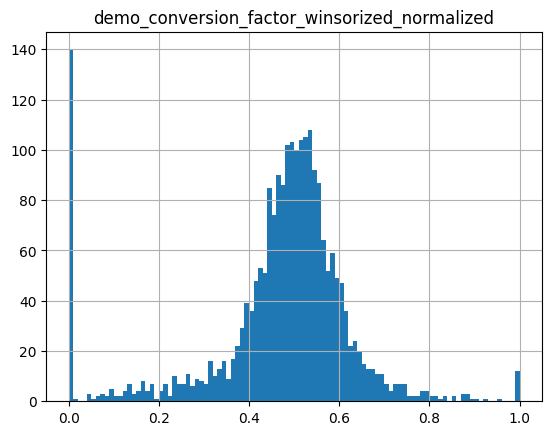

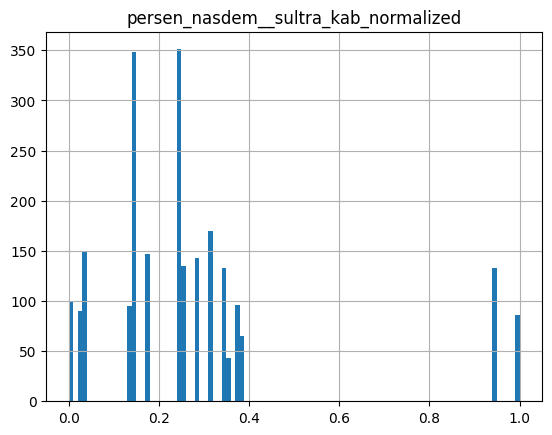

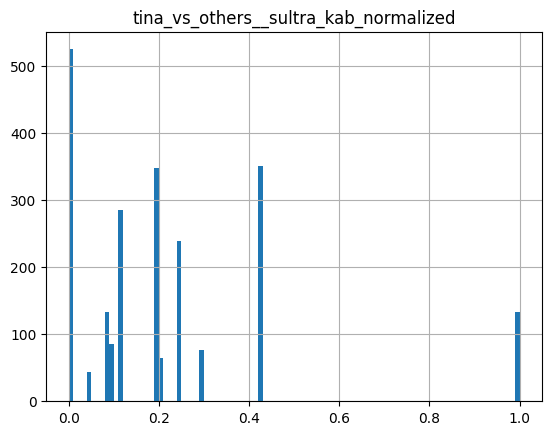

In [ ]:
# Normalization by standard scaler
from sklearn.preprocessing import MinMaxScaler
from scipy.stats.mstats import winsorize

# Define the limits for windsorizing (e.g., limit 5% from each end)
limits = [0.06, 0.005]  # Adjust these values as needed

# Apply windsorization
df_sultra['demo_conversion_factor_winsorized'] = winsorize(df_sultra['demo_conversion_factor'], limits=limits)

# Optionally, normalize the windsorized column
scaler = MinMaxScaler()
df_sultra[['demo_conversion_factor_winsorized_normalized']] = scaler.fit_transform(df_sultra['demo_conversion_factor_winsorized'].values.reshape(-1, 1))
df_sultra[['persen_nasdem__sultra_kab_normalized']] = scaler.fit_transform(df_sultra[['persen_nasdem__sultra_kab']].values.reshape(-1, 1))
df_sultra[['tina_vs_others__sultra_kab_normalized']] = scaler.fit_transform(df_sultra[['tina_vs_others__sultra_kab']].values.reshape(-1, 1))

# Plot the histograms
df_sultra[['demo_conversion_factor_winsorized_normalized']].hist(bins=100)
df_sultra[['persen_nasdem__sultra_kab_normalized']].hist(bins=100)
df_sultra[['tina_vs_others__sultra_kab_normalized']].hist(bins=100)


### Calculation

In [ ]:
# Define constants
effort_value = 0.7
effort_weight = 0.4
strength_tina_vs_others = 0.1
strength_nasdem = 0.1
demographic_suitability = 0.4
multiplier = 1.3

# Calculate final conversion rate
df_sultra[['final_conversion_rate']] =(df_sultra[['demo_conversion_factor_winsorized_normalized']] * demographic_suitability) 
+ (df_sultra[['persen_nasdem__sultra_kab_normalized']] * strength_nasdem)
+ (df_sultra[['tina_vs_others__sultra_kab_normalized']] * strength_tina_vs_others)

df_sultra[['final_conversion_rate']] = effort_value * (effort_weight + df_sultra[['final_conversion_rate']]) * multiplier
# df_sultra[['final_conversion_rate']].hist(bins=100)
# df_sultra[['final_conversion_rate']].mean()

# Calculate resource allocation factor based on conversion rate
# Calculate percentiles
percentile_25 = df_sultra['final_conversion_rate'].quantile(0.25)
percentile_75 = df_sultra['final_conversion_rate'].quantile(0.75)

# Define the function to apply the conditions
def apply_conditions(x):
    if x < percentile_25:
        return 0.7
    elif x > percentile_75:
        return 1.3
    else:
        return 1

# Apply the function to the 'effort_adjusted_conversion_rate' column
df_sultra['resource_factor'] = df_sultra['final_conversion_rate'].apply(apply_conditions)

# Calculate columns
df_sultra['converted_votes_if_all_approached'] = df_sultra['final_conversion_rate'] * df_sultra['asumsi_total_suara_dpt']

# Calculate weighted sumproduct of R and S
overtarget_factor = (df_sultra['converted_votes_if_all_approached'] * df_sultra['resource_factor']).sum() / df_sultra['asumsi_total_suara_dpt'].sum()




/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_85789/137601762.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_sultra[['final_conversion_rate']] =(df_sultra[['demo_conversion_factor_winsorized_normalized']] * demographic_suitability)
/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_85789/137601762.py:33: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_sultra['resource_factor'] = df_sultra['final_conversion_rate'].apply(apply_conditions)
/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_857

<Axes: >

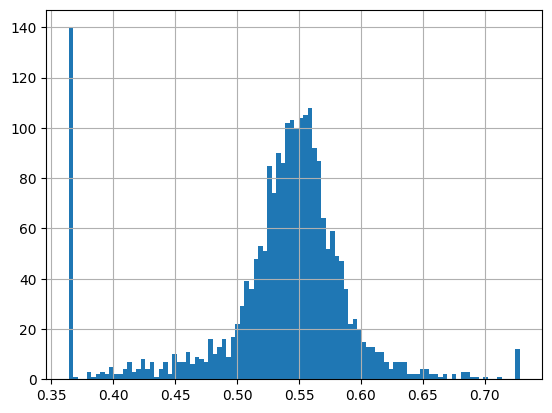

In [ ]:
df_sultra['final_conversion_rate'].hist(bins=100)

In [ ]:
# Constants
DPT_per_households = 2.55
households_per_volunteer_per_day = 3
valid_votes_per_DPT = 0.7
volunteer_target_households = 100

months_to_end_of_door_to_door = 5
working_days_per_month = 20

target_suara_35 = 0.35
target_suara_51 = 0.51


# Example DataFrame (replace this with your actual data)
# df_sultra = pd.DataFrame({
#     'converted_votes_if_all_approached': [100, 200, 300],
#     'resource_factor': [1, 0.9, 1.1],
#     'final_conversion_rate': [0.1, 0.2, 0.15]
# })

# Function to calculate metrics for a given target_suara
def calculate_metrics(df, target_suara, suffix):
    df[f'target_voters_{suffix}'] = (target_suara * df['converted_votes_if_all_approached'] * df['resource_factor']) / overtarget_factor
    df[f'no_of_people_reached_{suffix}'] = df[f'target_voters_{suffix}'] / df['final_conversion_rate']
    df[f'house_visit_target_{suffix}'] = df[f'no_of_people_reached_{suffix}'] / DPT_per_households
    # df[f'door_to_door_per_day_target_{suffix}'] = df[f'house_visit_target_{suffix}'] / (working_days_per_month * months_to_end_of_door_to_door)
    # df[f'volunteer_needs_{suffix}'] = df[f'door_to_door_per_day_target_{suffix}'] / households_per_volunteer_per_day
    df[f'volunteer_needs_{suffix}'] = df[f'house_visit_target_{suffix}'] / volunteer_target_households

# Calculate metrics for both targets
calculate_metrics(df_sultra, target_suara_35, '35')
calculate_metrics(df_sultra, target_suara_51, '51')

# Define the columns for export and plot
metrics_data_columns_35 = [
    'resource_factor', 
    'final_conversion_rate', 
    'target_voters_35', 
    'no_of_people_reached_35', 
    'house_visit_target_35', 
    # 'door_to_door_per_day_target_35', 
    'volunteer_needs_35'
]

metrics_data_columns_51 = [
    'resource_factor', 
    'final_conversion_rate', 
    'target_voters_51', 
    'no_of_people_reached_51', 
    'house_visit_target_51', 
    # 'door_to_door_per_day_target_51', 
    'volunteer_needs_51'
]

# Assuming base_data_columns is defined
# base_data_columns = ['column1', 'column2', 'column3']  # Replace with actual column names

df_sultra_export = df_sultra[base_data_columns + metrics_data_columns_35 + metrics_data_columns_51]
df_sultra_plot = df_sultra[base_data_columns + metrics_data_columns_35 + metrics_data_columns_51]


/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_85789/2391646786.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'volunteer_needs_{suffix}'] = df[f'house_visit_target_{suffix}'] / volunteer_target_households
/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_85789/2391646786.py:23: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'target_voters_{suffix}'] = (target_suara * df['converted_votes_if_all_approached'] * df['resource_factor']) / overtarget_factor
/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000

In [ ]:
df_sultra_plot.rename(columns={
    'asumsi_total_suara_dpt': 'Total Suara DPT',
    'target_voters_35': 'Target Suara 35%',
    'no_of_people_reached_35': 'Target Orang yang Ditemui 35%',
    'house_visit_target_35': 'Target Visit Rumah 35%',
    # 'door_to_door_per_day_target_35': 'Target D2D Perhari 35%',
    'volunteer_needs_35': 'Kebutuhan Relawan 35%',
    'target_voters_51': 'Target Suara 51%',
    'no_of_people_reached_51': 'Target Orang yang Ditemui 51%',
    'house_visit_target_51': 'Target Visit Rumah 51%',
    # 'door_to_door_per_day_target_51': 'Target D2D Perhari 51%',
    'volunteer_needs_51': 'Kebutuhan Relawan 51%'
}, inplace=True)

plot_list = [
    'Total Suara DPT', 
    'Target Suara 35%', 
    'Target Orang yang Ditemui 35%',
    'Target Visit Rumah 35%', 
    # 'Target D2D Perhari 35%', 
    'Kebutuhan Relawan 35%',
    'Target Suara 51%', 
    'Target Orang yang Ditemui 51%', 
    'Target Visit Rumah 51%',
    # 'Target D2D Perhari 51%', 
    'Kebutuhan Relawan 51%'

]

kel_list = list(df_sultra_plot.nama_kel_desa.unique())
kec_list = list(df_sultra_plot.nama_kecamatan.unique())
kab_list = list(df_sultra_plot.nama_kab_kota.unique())

df_sultra_plot

/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_85789/2163256660.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sultra_plot.rename(columns={


,kode_provinsi,kode_kab_kota,kode_kec,kode_kel_desa,nama_provinsi,nama_kab_kota,nama_kecamatan,nama_kel_desa,paslon01,paslon02,...,Target Suara 35%,Target Orang yang Ditemui 35%,Target Visit Rumah 35%,Kebutuhan Relawan 35%,resource_factor,final_conversion_rate,Target Suara 51%,Target Orang yang Ditemui 51%,Target Visit Rumah 51%,Kebutuhan Relawan 51%
267,74,74.01,74.01.01,74.01.01.2008,Sulawesi Tenggara,Kolaka,Wundulako,Unamendaa,235,893,...,319.556815,607.95,238.411765,2.384118,1.0,0.525630,465.639931,885.87,347.4,3.474
268,74,74.01,74.01.01,74.01.01.1001,Sulawesi Tenggara,Kolaka,Wundulako,19 Nopember,358,1505,...,557.735695,1016.75,398.72549,3.987255,1.0,0.548548,812.700584,1481.55,581.0,5.81
269,74,74.01,74.01.01,74.01.01.1004,Sulawesi Tenggara,Kolaka,Wundulako,Kowioha,415,868,...,505.477056,860.86,337.592157,3.375922,1.3,0.587177,736.552282,1254.396,491.92,4.9192
270,74,74.01,74.01.01,74.01.01.1005,Sulawesi Tenggara,Kolaka,Wundulako,Silea,254,1062,...,497.090227,862.225,338.127451,3.381275,1.3,0.576520,724.331474,1256.385,492.7,4.927
271,74,74.01,74.01.01,74.01.01.2010,Sulawesi Tenggara,Kolaka,Wundulako,Sabiona,232,706,...,268.018974,475.3,186.392157,1.863922,1.0,0.563894,390.541933,692.58,271.6,2.716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2547,74,74.15,74.15.04,74.15.04.2001,Sulawesi Tenggara,Buton Selatan,Batu Atas,Batuatas Liwu,0,0,...,0.0,0.0,0.0,0.0,1.0,0.542755,0.0,0.0,0.0,0.0
2548,74,74.15,74.15.04,74.15.04.2004,Sulawesi Tenggara,Buton Selatan,Batu Atas,Batu Atas Timur,0,0,...,0.0,0.0,0.0,0.0,1.0,0.556606,0.0,0.0,0.0,0.0
2549,74,74.15,74.15.07,74.15.07.2010,Sulawesi Tenggara,Buton Selatan,Kadatua,Kapoa Barat,0,0,...,0.0,0.0,0.0,0.0,1.0,0.546402,0.0,0.0,0.0,0.0
2550,74,74.71,74.71.09,74.71.09.1005,Sulawesi Tenggara,Kota Kendari,Puuwatu,Abeli Dalam,0,0,...,0.0,0.0,0.0,0.0,1.0,0.552952,0.0,0.0,0.0,0.0


In [ ]:
df_sultra_plot[df_sultra_plot.nama_kab_kota != 0]

,kode_provinsi,kode_kab_kota,kode_kec,kode_kel_desa,nama_provinsi,nama_kab_kota,nama_kecamatan,nama_kel_desa,paslon01,paslon02,...,Target Suara 35%,Target Orang yang Ditemui 35%,Target Visit Rumah 35%,Kebutuhan Relawan 35%,resource_factor,final_conversion_rate,Target Suara 51%,Target Orang yang Ditemui 51%,Target Visit Rumah 51%,Kebutuhan Relawan 51%
267,74,74.01,74.01.01,74.01.01.2008,Sulawesi Tenggara,Kolaka,Wundulako,Unamendaa,235,893,...,319.556815,607.95,238.411765,2.384118,1.0,0.525630,465.639931,885.87,347.4,3.474
268,74,74.01,74.01.01,74.01.01.1001,Sulawesi Tenggara,Kolaka,Wundulako,19 Nopember,358,1505,...,557.735695,1016.75,398.72549,3.987255,1.0,0.548548,812.700584,1481.55,581.0,5.81
269,74,74.01,74.01.01,74.01.01.1004,Sulawesi Tenggara,Kolaka,Wundulako,Kowioha,415,868,...,505.477056,860.86,337.592157,3.375922,1.3,0.587177,736.552282,1254.396,491.92,4.9192
270,74,74.01,74.01.01,74.01.01.1005,Sulawesi Tenggara,Kolaka,Wundulako,Silea,254,1062,...,497.090227,862.225,338.127451,3.381275,1.3,0.576520,724.331474,1256.385,492.7,4.927
271,74,74.01,74.01.01,74.01.01.2010,Sulawesi Tenggara,Kolaka,Wundulako,Sabiona,232,706,...,268.018974,475.3,186.392157,1.863922,1.0,0.563894,390.541933,692.58,271.6,2.716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2547,74,74.15,74.15.04,74.15.04.2001,Sulawesi Tenggara,Buton Selatan,Batu Atas,Batuatas Liwu,0,0,...,0.0,0.0,0.0,0.0,1.0,0.542755,0.0,0.0,0.0,0.0
2548,74,74.15,74.15.04,74.15.04.2004,Sulawesi Tenggara,Buton Selatan,Batu Atas,Batu Atas Timur,0,0,...,0.0,0.0,0.0,0.0,1.0,0.556606,0.0,0.0,0.0,0.0
2549,74,74.15,74.15.07,74.15.07.2010,Sulawesi Tenggara,Buton Selatan,Kadatua,Kapoa Barat,0,0,...,0.0,0.0,0.0,0.0,1.0,0.546402,0.0,0.0,0.0,0.0
2550,74,74.71,74.71.09,74.71.09.1005,Sulawesi Tenggara,Kota Kendari,Puuwatu,Abeli Dalam,0,0,...,0.0,0.0,0.0,0.0,1.0,0.552952,0.0,0.0,0.0,0.0


In [ ]:
# numeric_cols = df_sultra_plot.select_dtypes(include=['number']).columns.tolist()
# non_numeric_cols = df_sultra_plot.select_dtypes(exclude=['number']).columns.tolist()
# ratio_cols = ['resource_factor', 'final_conversion_rate']

# agg_dict = {col: 'sum' for col in numeric_cols}
# agg_dict.update({col: 'mean' for col in ratio_cols})
# agg_dict.update({col: any_value for col in non_numeric_cols})

# agg_dict

In [ ]:
df_sultra_plot.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2285 entries, 267 to 2551
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   kode_provinsi                  2285 non-null   object 
 1   kode_kab_kota                  2285 non-null   object 
 2   kode_kec                       2285 non-null   object 
 3   kode_kel_desa                  2285 non-null   object 
 4   nama_provinsi                  2285 non-null   object 
 5   nama_kab_kota                  2285 non-null   object 
 6   nama_kecamatan                 2285 non-null   object 
 7   nama_kel_desa                  2285 non-null   object 
 8   paslon01                       2285 non-null   Int64  
 9   paslon02                       2285 non-null   Int64  
 10  paslon03                       2285 non-null   Int64  
 11  total_suara_sah                2285 non-null   Int64  
 12  suara_tidak_sah                2285 non-null   Int6

In [ ]:
import pandas as pd
import geopandas as gpd

def any_value(series):
    return series.iloc[0]

def make_unique(column_name, existing_names):
    """Helper function to make column names unique."""
    counter = 1
    new_name = column_name
    while new_name in existing_names:
        new_name = f"{column_name}_{counter}"
        counter += 1
    return new_name

def join_geojson_sultra(df_kel_source):
    kelurahan_geojson = 'data_2/geojson/Sulawesi Tenggara_DESA_KELURAHAN.geojson'
    kecamatan_geojson = 'data_2/geojson/Sulawesi Tenggara_KECAMATAN.geojson'
    kabupaten_geojson = 'data_2/geojson/Sulawesi Tenggara_KAB_KOTA.geojson'

    gdf_kel = gpd.read_file(kelurahan_geojson)
    gdf_kec = gpd.read_file(kecamatan_geojson)
    gdf_kab = gpd.read_file(kabupaten_geojson)

    df_kel = df_kel_source.copy()

    # Ensure unique column names
    new_columns = []
    existing_names = set()
    for col in df_kel.columns:
        unique_col = make_unique(col, existing_names)
        new_columns.append(unique_col)
        existing_names.add(unique_col)
    df_kel.columns = new_columns

    # Select numeric and non-numeric columns
    numeric_cols = df_kel.select_dtypes(include=['number']).columns.tolist()
    non_numeric_cols = df_kel.select_dtypes(exclude=['number']).columns.tolist()
    ratio_cols = ['resource_factor', 'final_conversion_rate']

    # Remove grouping columns from non-numeric columns
    non_numeric_cols = [col for col in non_numeric_cols if col not in ['kode_kec', 'kode_kab_kota']]

    # Create aggregation dictionary
    agg_dict = {col: 'sum' for col in numeric_cols}
    agg_dict.update({col: 'mean' for col in ratio_cols})
    agg_dict.update({col: any_value for col in non_numeric_cols})

    print("Aggregation Dictionary: ", agg_dict)

    # Group by and aggregate
    df_kec = df_kel.groupby(by='kode_kec').agg(agg_dict).reset_index()
    df_kab_kota = df_kel.groupby(by='kode_kab_kota').agg(agg_dict).reset_index()

    for col in [col for col in numeric_cols if col not in ratio_cols]:
        df_kel[col] = df_kel[col].apply(round)
        df_kec[col] = df_kec[col].astype(int)
        df_kab_kota[col] = df_kab_kota[col].astype(int)
        
    # Merge GeoDataFrames with aggregated data
    gdf_merge_kel = pd.merge(gdf_kel, df_kel, left_on='KODE_KEL_DESA', right_on='kode_kel_desa', how='left')
    gdf_merge_kec = pd.merge(gdf_kec, df_kec, left_on='KODE_KEC', right_on='kode_kec', how='left')
    gdf_merge_kab_kota = pd.merge(gdf_kab, df_kab_kota, left_on='KODE_KAB_KOTA', right_on='kode_kab_kota', how='left')
    
    return gdf_merge_kel, gdf_merge_kec, gdf_merge_kab_kota

# Example usage with df_sultra_export DataFrame
gdf_merge_kel_sultra, gdf_merge_kec_sultra, gdf_merge_kab_kota_sultra = join_geojson_sultra(df_sultra_plot)


NameError: name 'df_sultra_plot' is not defined

In [ ]:
df_sultra_plot[df_sultra_plot['nama_kab_kota'] == 'Buton Utara']

NameError: name 'df_sultra_plot' is not defined

In [ ]:
os.makedirs('plot_results/RTV_weighted/kab_kota', exist_ok=True)

In [ ]:

# Function to download tiles for a given data extent and zoom level
def cache_tiles(data, zoom):
    bounds = data.total_bounds  # Get the bounding box of the data
    # Get the tile bounds at the given zoom level
    tiles = list(mercantile.tiles(bounds[0], bounds[1], bounds[2], bounds[3], zoom))
    
    # Create a temporary directory to store tiles
    with tempfile.TemporaryDirectory() as tmpdirname:
        def download_tile(tile):
            temp_file = os.path.join(tmpdirname, f'{tile.z}_{tile.x}_{tile.y}.tif')
            cx.bounds2raster(*mercantile.xy_bounds(tile), temp_file, source=cx.providers.CartoDB.PositronNoLabels)
            # return f'Tile {tile} cached.'

        with ThreadPoolExecutor(max_workers=100) as executor:
            futures = [executor.submit(download_tile, tile) for tile in tiles]
            for future in tqdm(as_completed(futures), total=len(futures), desc='Caching tiles'):
                result = future.result()
                # print(result)


In [ ]:


def map_numeric_kabupaten(data, col):
    fig, ax = plt.subplots(figsize=(10, 15))
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", size="3%", pad=0.1)

    data.plot(ax=ax,
        column=col,
        edgecolor='k',
        cmap='Reds',
        linewidth=0.5,
        legend=True,  
        alpha=0.7,
        cax=cax,
        categorical=False,
        legend_kwds={"orientation": "horizontal"},
        missing_kwds={
            "color": "black",
            "edgecolor": "red",
            "label": "Missing values",
        }
    )

    cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels, crs=data.crs, zoom=10)
    ax.set_axis_off()

    title_font = {'fontsize': 20, 'fontweight': 'bold', 'fontname': 'Helvetica'}
    ax.set_title(f"Peta {col}".upper(), pad=2, loc='left', fontsize=title_font['fontsize'], fontdict=title_font)

    for idx, row in data.iterrows():
        centroid = row.geometry.centroid
        label = f"{row['NAMA_KAB_KOTA']}\n{row[col]:,.0f}"
        ax.text(
            centroid.x, centroid.y, str(label),
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=8,
            color='black',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0.5)
        )
    os.makedirs('plot_results/RTV_weighted/kab_kota', exist_ok=True)
    filename = f'plot_results/RTV_weighted/kab_kota/map_of_{col}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close(fig)

# Cache tiles
# cache_tiles(gdf_merge_kab_kota_sultra, zoom=10)

# for item in plot_list:
#     map_numeric_kabupaten(gdf_merge_kab_kota_sultra, item)
#     print(f'{item} is done plotting')


Total Suara DPT is done plotting
Target Suara 35% is done plotting
Target Orang yang Ditemui 35% is done plotting
Target Visit Rumah 35% is done plotting
Kebutuhan Relawan 35% is done plotting
Target Suara 51% is done plotting
Target Orang yang Ditemui 51% is done plotting
Target Visit Rumah 51% is done plotting
Kebutuhan Relawan 51% is done plotting


## Kecamatan

In [ ]:
def map_numeric_kecamatan(data, col):
    fig, ax = plt.subplots(figsize = (10,15))
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", size="3%", pad=0.1)

    map = data.plot(ax=ax,
        column=col,
        edgecolor = 'k',
        cmap = 'Reds',
        linewidth = 0.5,
        legend= True,  
        alpha = 0.7,
        cax = cax,
        categorical = False,
        legend_kwds={"orientation": "horizontal"},
            missing_kwds={
            "color": "black",
            "edgecolor": "red",
            # "hatch": "///",
            "label": "Missing values",
        }, 
        )


    map = cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels, crs=data.crs, zoom=12)
    map = ax.set_axis_off()

    title_font = {'fontsize': 20, 'fontweight': 'bold', 'fontname': 'Helvetica'}  # Adjust the font properties as needed
    map = ax.set_title(f"Peta {col} di {kabupaten}".upper(), pad=2, loc='left', fontsize=title_font['fontsize'],  fontdict=title_font)

    # Add labels to each geometry
    for idx, row in data.iterrows():
        # Get the centroid for placing the label
        centroid = row.geometry.centroid
        label = f"{row['NAMA_KECAMATAN']}\n{row[col]}"
        # Use `ax.text` to place the label
        # Adjust horizontal and vertical alignment and offset if needed
        ax.text(
            centroid.x, centroid.y, str(label),
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=6,  # Adjust the fontsize as needed
            color='black',  # Choose a color that contrasts with your map
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0.5)  # Optional: add a background to the text
        )

     # Ensure the directory exists
    directory = f'plot_results/RTV_weighted/kab_kota/{kabupaten}'
    if not os.path.exists(directory):
        os.makedirs(directory)

    # Save the plot to a file
    filename = f'{directory}/map_of_{col}.png'  # Construct the filename
    plt.savefig(filename, dpi=300, bbox_inches='tight')  # Save the figure

    plt.close(fig)  # Close the figure to free memory
    

# Cache tiles
# cache_tiles(gdf_merge_kec_sultra, zoom=12)

# for kabupaten in kab_list:
#     for item in plot_list:
#         map_numeric_kecamatan(gdf_merge_kec_sultra[gdf_merge_kec_sultra.NAMA_KAB_KOTA == kabupaten], item)
#         print(f'{kabupaten}_{item} is done plotting')

Kolaka_Total Suara DPT is done plotting
Kolaka_Target Suara 35% is done plotting
Kolaka_Target Orang yang Ditemui 35% is done plotting
Kolaka_Target Visit Rumah 35% is done plotting
Kolaka_Kebutuhan Relawan 35% is done plotting
Kolaka_Target Suara 51% is done plotting
Kolaka_Target Orang yang Ditemui 51% is done plotting
Kolaka_Target Visit Rumah 51% is done plotting
Kolaka_Kebutuhan Relawan 51% is done plotting
Konawe_Total Suara DPT is done plotting
Konawe_Target Suara 35% is done plotting
Konawe_Target Orang yang Ditemui 35% is done plotting
Konawe_Target Visit Rumah 35% is done plotting
Konawe_Kebutuhan Relawan 35% is done plotting
Konawe_Target Suara 51% is done plotting
Konawe_Target Orang yang Ditemui 51% is done plotting
Konawe_Target Visit Rumah 51% is done plotting
Konawe_Kebutuhan Relawan 51% is done plotting


/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_85789/1386395124.py:6: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  map = data.plot(ax=ax,


0_Total Suara DPT is done plotting


/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_85789/1386395124.py:6: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  map = data.plot(ax=ax,


0_Target Suara 35% is done plotting


...

0_Target Orang yang Ditemui 51% is done plotting


/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_85789/1386395124.py:6: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  map = data.plot(ax=ax,


0_Target Visit Rumah 51% is done plotting


/var/folders/2_/ldxvm2xd3h94sjq_pyr15mmm0000gp/T/ipykernel_85789/1386395124.py:6: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  map = data.plot(ax=ax,


0_Kebutuhan Relawan 51% is done plotting
Muna_Total Suara DPT is done plotting
Muna_Target Suara 35% is done plotting
Muna_Target Orang yang Ditemui 35% is done plotting
Muna_Target Visit Rumah 35% is done plotting
Muna_Kebutuhan Relawan 35% is done plotting
Muna_Target Suara 51% is done plotting
Muna_Target Orang yang Ditemui 51% is done plotting
Muna_Target Visit Rumah 51% is done plotting
Muna_Kebutuhan Relawan 51% is done plotting
Buton_Total Suara DPT is done plotting
Buton_Target Suara 35% is done plotting
Buton_Target Orang yang Ditemui 35% is done plotting
Buton_Target Visit Rumah 35% is done plotting
Buton_Kebutuhan Relawan 35% is done plotting
Buton_Target Suara 51% is done plotting
Buton_Target Orang yang Ditemui 51% is done plotting
Buton_Target Visit Rumah 51% is done plotting
Buton_Kebutuhan Relawan 51% is done plotting
Konawe Selatan_Total Suara DPT is done plotting
Konawe Selatan_Target Suara 35% is done plotting
Konawe Selatan_Target Orang yang Ditemui 35% is done plot

In [ ]:
def map_numeric_kelurahan(data, col, kabupaten, kecamatan):
    # Calculate thresholds for top, mid, and low 33%
    top_threshold = np.percentile(data[col], 66)
    mid_threshold = np.percentile(data[col], 33)
    
    def get_priority(value):
        if value >= top_threshold:
            return "Very High Priority"
        elif value >= mid_threshold:
            return "High Priority"
        else:
            return "Mid Priority"

    fig, ax = plt.subplots(figsize=(10, 15))
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("bottom", size="3%", pad=0.1)

    data.plot(ax=ax,
        column=col,
        edgecolor='k',
        cmap='Reds',
        linewidth=0.5,
        legend=True,  
        alpha=0.7,
        cax=cax,
        categorical=False,
        legend_kwds={"orientation": "horizontal"},
        missing_kwds={
            "color": "black",
            "edgecolor": "red",
            "label": "Missing values",
        }
    )

    cx.add_basemap(ax, source=cx.providers.CartoDB.PositronNoLabels, crs=data.crs, zoom=15)
    ax.set_axis_off()

    title_font = {'fontsize': 20, 'fontweight': 'bold', 'fontname': 'Helvetica'}
    ax.set_title(f"Peta {col} di {kabupaten}, {kecamatan}".upper(), pad=2, loc='left', fontsize=title_font['fontsize'], fontdict=title_font)

    for idx, row in data.iterrows():
        centroid = row.geometry.centroid
        priority = get_priority(row[col])
        if col in ['Kebutuhan Relawan 35%', 'Kebutuhan Relawan 51%']:
            label = f"{row['NAMA_KEL_DESA']}\n{priority}"
        else:
            label = f"{row['NAMA_KEL_DESA']}\n{int(np.ceil(row[col]))}"
        ax.text(
            centroid.x, centroid.y, str(label),
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=6,
            color='black',
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0.5)
        )

    directory = f'plot_results/RTV_weighted/kab_kota/{kabupaten}/{kecamatan}'
    if not os.path.exists(directory):
        os.makedirs(directory)

    filename = f'{directory}/map_of_{col}.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close(fig)

In [ ]:

# # Example usage
# cache_tiles(gdf_merge_kel_sultra, zoom=15)

In [ ]:
# # Test Plot
# kab_list_test = ['Konawe Selatan']

# for kabupaten in kab_list_test:
#     kab_gdf = gdf_merge_kel_sultra[gdf_merge_kel_sultra.NAMA_KAB_KOTA == kabupaten]
#     kec_list = ['Laeya', 'Lalembuu', 'Lainea']
#     for kecamatan in kec_list:
#         for item in plot_list:
#             map_numeric_kelurahan(kab_gdf[kab_gdf.NAMA_KECAMATAN == kecamatan], item, kabupaten, kecamatan)
#             print(f'{kabupaten}_{kecamatan}_{item} is done plotting')

In [ ]:
# from multiprocessing import Pool

# def run_plot_task(args):
#     data_path, col, kabupaten, kecamatan = args
#     return map_numeric_kelurahan(data_path, col, kabupaten, kecamatan)

# def prepare_task(kab_gdf, item, kabupaten, kecamatan):
#     data_path = f'temp/temp_data_{kabupaten}_{kecamatan}_{item}.geojson'
#     os.makedirs(os.path.dirname(data_path), exist_ok=True)
        
#     # Convert any Float64Dtype columns to standard float
#     for column in kab_gdf.select_dtypes(include=[pd.Float64Dtype()]).columns:
#         kab_gdf[column] = kab_gdf[column].astype(float)
    
#     kab_gdf.to_file(data_path, driver='GeoJSON')
#     return (data_path, item, kabupaten, kecamatan)

# # Test Plot
# kab_list_test = ['Konawe Selatan']
# kec_list = ['Laeya', 'Lalembuu', 'Lainea']
# plot_list = [
#     'Total Suara DPT', 
#     'Target Suara 35%', 
#     'Target Orang yang Ditemui 35%',
#     'Target Visit Rumah 35%', 
#     'Target D2D Perhari 35%', 
#     'Kebutuhan Relawan 35%',
#     'Target Suara 51%', 
#     'Target Orang yang Ditemui 51%', 
#     'Target Visit Rumah 51%',
#     'Target D2D Perhari 51%', 
#     'Kebutuhan Relawan 51%'

# ]  # Replace with actual column names

# tasks = []

# for kabupaten in kab_list_test:
#     kab_gdf = gdf_merge_kel_sultra[gdf_merge_kel_sultra.NAMA_KAB_KOTA == kabupaten]
#     for kecamatan in kec_list:
#         for item in plot_list:
#             tasks.append(prepare_task(kab_gdf[kab_gdf.NAMA_KECAMATAN == kecamatan], item, kabupaten, kecamatan))

# with Pool(processes=10) as pool:
#     for result in tqdm(pool.imap_unordered(run_plot_task, tasks), total=len(tasks), desc='Plotting maps'):
#         print(result)

In [ ]:
print(kab_list)

kab_list = ['Kolaka', 'Konawe', 'Muna', 'Buton', 'Konawe Selatan', 'Bombana', 'Wakatobi', 'Kolaka Utara', 'Konawe Utara', 'Buton Utara', 'Kolaka Timur', 'Konawe Kepulauan', 'Muna Barat', 'Buton Tengah', 'Buton Selatan', 'Kota Kendari', 'Kota Bau Bau']
kab_list.sort()

['Kolaka', 'Konawe', 0, 'Muna', 'Buton', 'Konawe Selatan', 'Bombana', 'Wakatobi', 'Kolaka Utara', 'Konawe Utara', 'Buton Utara', 'Kolaka Timur', 'Konawe Kepulauan', 'Muna Barat', 'Buton Tengah', 'Buton Selatan', 'Kota Kendari', 'Kota Bau Bau']


In [ ]:
len(kab_list)

17

In [ ]:
import os

kab_plot = [kab_list[province_index]]
overwrite = True  # Set this to True or False as needed

for kabupaten in kab_plot:
    kab_gdf = gdf_merge_kel_sultra[gdf_merge_kel_sultra.NAMA_KAB_KOTA == kabupaten]
    kec_list = kab_gdf.NAMA_KECAMATAN.unique()
    
    for kecamatan in kec_list:
        for item in plot_list:
            file_name = f'{kabupaten}_{kecamatan}_{item}.png'
            if not overwrite and os.path.exists(file_name):
                print(f'Skipping plotting for {kabupaten}_{kecamatan}_{item} as file already exists.')
            else:
                map_numeric_kelurahan(kab_gdf[kab_gdf.NAMA_KECAMATAN == kecamatan], item, kabupaten, kecamatan)
                print(f'{kabupaten}_{kecamatan}_{item} is done plotting')


Bombana_Poleang Selatan_Total Suara DPT is done plotting
Bombana_Poleang Selatan_Target Suara 35% is done plotting
Bombana_Poleang Selatan_Target Orang yang Ditemui 35% is done plotting
Bombana_Poleang Selatan_Target Visit Rumah 35% is done plotting
Bombana_Poleang Selatan_Kebutuhan Relawan 35% is done plotting
Bombana_Poleang Selatan_Target Suara 51% is done plotting
Bombana_Poleang Selatan_Target Orang yang Ditemui 51% is done plotting
Bombana_Poleang Selatan_Target Visit Rumah 51% is done plotting
Bombana_Poleang Selatan_Kebutuhan Relawan 51% is done plotting
Bombana_Poleang Barat_Total Suara DPT is done plotting
Bombana_Poleang Barat_Target Suara 35% is done plotting
Bombana_Poleang Barat_Target Orang yang Ditemui 35% is done plotting
Bombana_Poleang Barat_Target Visit Rumah 35% is done plotting
Bombana_Poleang Barat_Kebutuhan Relawan 35% is done plotting
Bombana_Poleang Barat_Target Suara 51% is done plotting
Bombana_Poleang Barat_Target Orang yang Ditemui 51% is done plotting
Bom

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_squared_error
# from sklearn.preprocessing import StandardScaler

# # Select features and target
# features = normalized_columns + sultra_columns + other_metrics
# X = df_sultra[features]
# y = df_sultra['estimasi_suara_tina_nur_alam']

# # # Standardize features
# # scaler = StandardScaler()
# # X_scaled = scaler.fit_transform(X)

# # Split data
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Train and evaluate models
# models = {
#     'Linear Regression': LinearRegression(),
#     'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
#     'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
# }

# results = {}
# for name, model in models.items():
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     mse = mean_squared_error(y_test, y_pred)
#     results[name] = {
#         'model': model,
#         'mse': mse,
#         'feature_importances': model.feature_importances_ if hasattr(model, 'feature_importances_') else model.coef_
#     }

# # Print results
# for name, result in results.items():
#     print(f"{name}:")
#     print(f"  MSE: {result['mse']}")
#     print(f"  Feature Importances: {result['feature_importances']}\n")

# # Combine feature importances for visualization
# importances = pd.DataFrame({
#     'Feature': features,
#     'Linear Regression': results['Linear Regression']['feature_importances'],
#     'Random Forest': results['Random Forest']['feature_importances'],
#     'Gradient Boosting': results['Gradient Boosting']['feature_importances']
# })

# print(importances)